In [2]:
!pip install prophet

In [4]:
#import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from prophet import Prophet

In [5]:
#load Dataset
df=pd.read_csv("C:/Users/HP/OneDrive/Desktop/Weather_ Analysis_ Project/data/bengaluru.csv")

In [6]:
#See first rows
df.head()

,date_time,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,uvIndex.1,moon_illumination,moonrise,moonset,...,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
0,2009-01-01 00:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,18,11,2,91,0.0,1014,14,10,109,8
1,2009-01-01 01:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,17,9,2,93,0.0,1014,14,7,85,6
2,2009-01-01 02:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,16,7,2,94,0.0,1014,13,5,61,4
3,2009-01-01 03:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,15,5,2,96,0.0,1014,12,2,37,3
4,2009-01-01 04:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,18,5,1,88,0.0,1015,14,5,45,3


In [7]:
#Check Columns
df.columns

Index(['date_time', 'maxtempC', 'mintempC', 'totalSnow_cm', 'sunHour',
       'uvIndex', 'uvIndex.1', 'moon_illumination', 'moonrise', 'moonset',
       'sunrise', 'sunset', 'DewPointC', 'FeelsLikeC', 'HeatIndexC',
       'WindChillC', 'WindGustKmph', 'cloudcover', 'humidity', 'precipMM',
       'pressure', 'tempC', 'visibility', 'winddirDegree', 'windspeedKmph'],
      dtype='object')

In [9]:
#Check Missing Values
df.isnull().sum()

date_time            0
maxtempC             0
mintempC             0
totalSnow_cm         0
sunHour              0
uvIndex              0
uvIndex.1            0
moon_illumination    0
moonrise             0
moonset              0
sunrise              0
sunset               0
DewPointC            0
FeelsLikeC           0
HeatIndexC           0
WindChillC           0
WindGustKmph         0
cloudcover           0
humidity             0
precipMM             0
pressure             0
tempC                0
visibility           0
winddirDegree        0
windspeedKmph        0
dtype: int64

In [11]:
#Convert Date Column
df['date_time'] = pd.to_datetime(df['date_time'])
df.head()

,date_time,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,uvIndex.1,moon_illumination,moonrise,moonset,...,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
0,2009-01-01 00:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,18,11,2,91,0.0,1014,14,10,109,8
1,2009-01-01 01:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,17,9,2,93,0.0,1014,14,7,85,6
2,2009-01-01 02:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,16,7,2,94,0.0,1014,13,5,61,4
3,2009-01-01 03:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,15,5,2,96,0.0,1014,12,2,37,3
4,2009-01-01 04:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,18,5,1,88,0.0,1015,14,5,45,3


In [13]:
#Select Important Columns
weather = df[[
    'date_time',
    'tempC',
    'humidity',
    'precipMM',
    'windspeedKmph'
]]

In [14]:
#View Clean Data
weather.head()

,date_time,tempC,humidity,precipMM,windspeedKmph
0,2009-01-01 00:00:00,14,91,0.0,8
1,2009-01-01 01:00:00,14,93,0.0,6
2,2009-01-01 02:00:00,13,94,0.0,4
3,2009-01-01 03:00:00,12,96,0.0,3
4,2009-01-01 04:00:00,14,88,0.0,3


In [15]:
#Basic Statistics
weather.describe()

,date_time,tempC,humidity,precipMM,windspeedKmph
count,96432,96432.000000,96432.000000,96432.000000,96432.000000
mean,2014-07-02 23:30:00,23.979810,64.895460,0.077719,12.448938
min,2009-01-01 00:00:00,0.000000,6.000000,0.000000,0.000000
25%,2011-10-02 11:45:00,21.000000,49.000000,0.000000,8.000000
50%,2014-07-02 23:30:00,23.000000,68.000000,0.000000,12.000000
75%,2017-04-02 11:15:00,27.000000,83.000000,0.000000,16.000000
max,2020-01-01 23:00:00,40.000000,100.000000,16.900000,41.000000
std,NaN,4.540028,21.856869,0.385865,5.716769


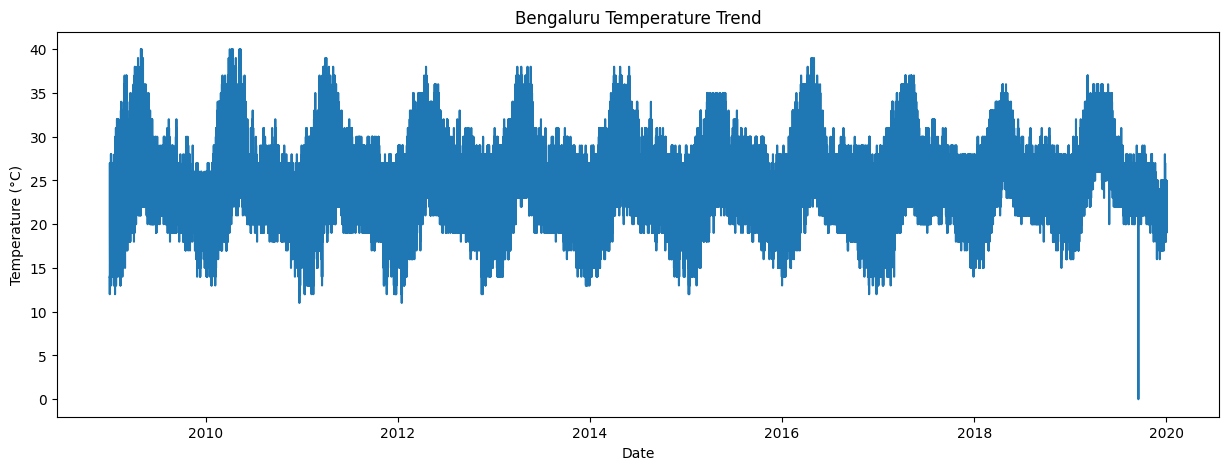

In [18]:
#Temperature Trend Graph
plt.figure(figsize=(15,5))

plt.plot(
    weather['date_time'],
    weather['tempC']
)

plt.title('Bengaluru Temperature Trend')

plt.xlabel('Date')

plt.ylabel('Temperature (°C)')

plt.show()

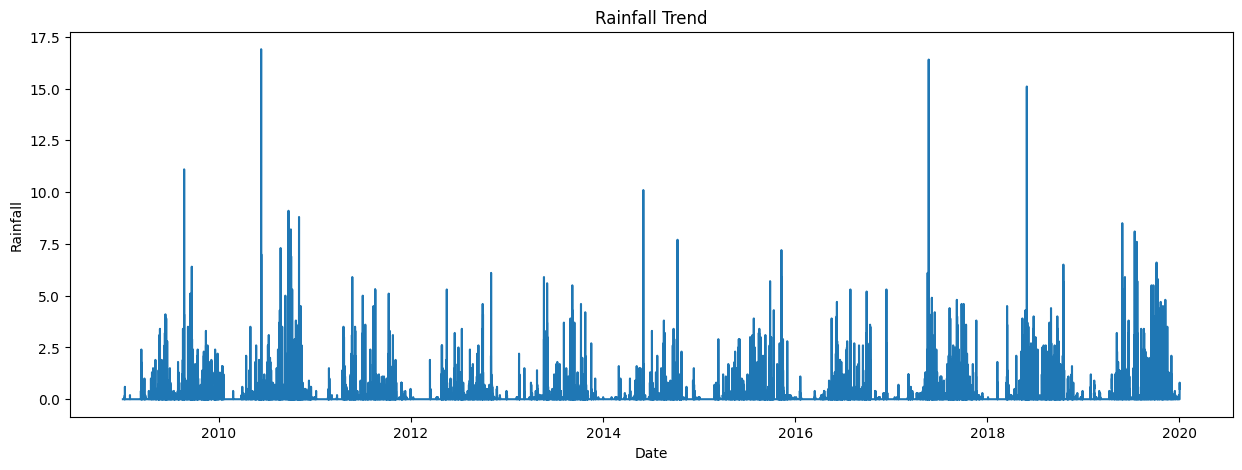

In [17]:
#Rainfall Graph
plt.figure(figsize=(15,5))

plt.plot(
    weather['date_time'],
    weather['precipMM']
)

plt.title('Rainfall Trend')

plt.xlabel('Date')

plt.ylabel('Rainfall')

plt.show()

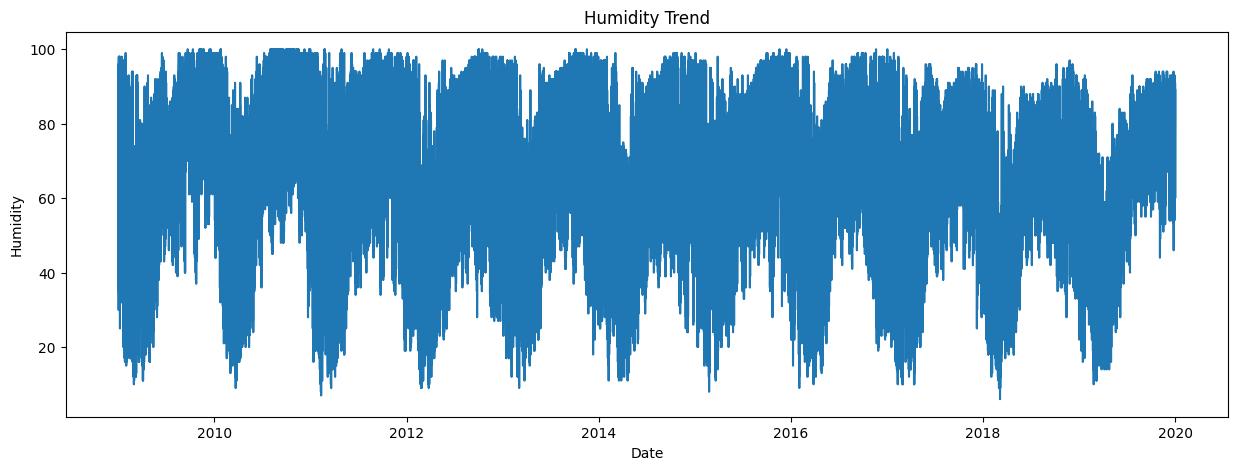

In [19]:
#Humidity Graph
plt.figure(figsize=(15,5))

plt.plot(
    weather['date_time'],
    weather['humidity']
)

plt.title('Humidity Trend')

plt.xlabel('Date')

plt.ylabel('Humidity')

plt.show()

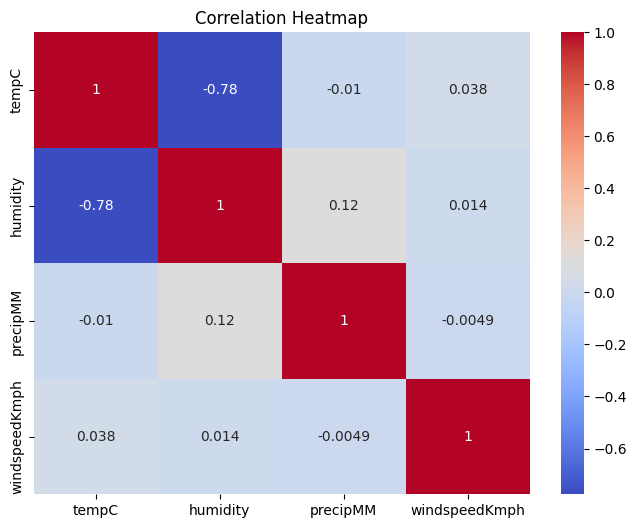

In [20]:
#Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    weather.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

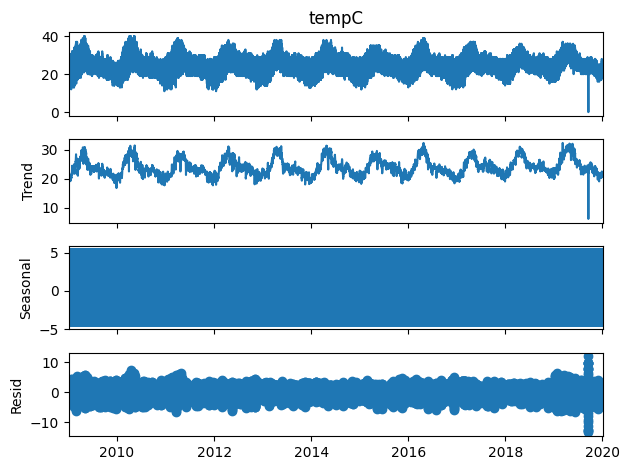

In [21]:
#Seasonal Decomposition
temp_data = weather.set_index('date_time')

result = seasonal_decompose(
    temp_data['tempC'],
    model='additive',
    period=24
)

result.plot()

plt.show()

In [22]:
#Anomaly Detection
mean = weather['tempC'].mean()

std = weather['tempC'].std()

threshold = mean + 2*std

anomalies = weather[
    weather['tempC'] > threshold
]

print(anomalies.head())

               date_time  tempC  humidity  precipMM  windspeedKmph
1044 2009-02-13 12:00:00     34        18       0.0              2
1284 2009-02-23 12:00:00     34        16       0.0             13
1305 2009-02-24 09:00:00     34        22       0.0              4
1306 2009-02-24 10:00:00     34        20       0.0              5
1307 2009-02-24 11:00:00     34        18       0.0              6


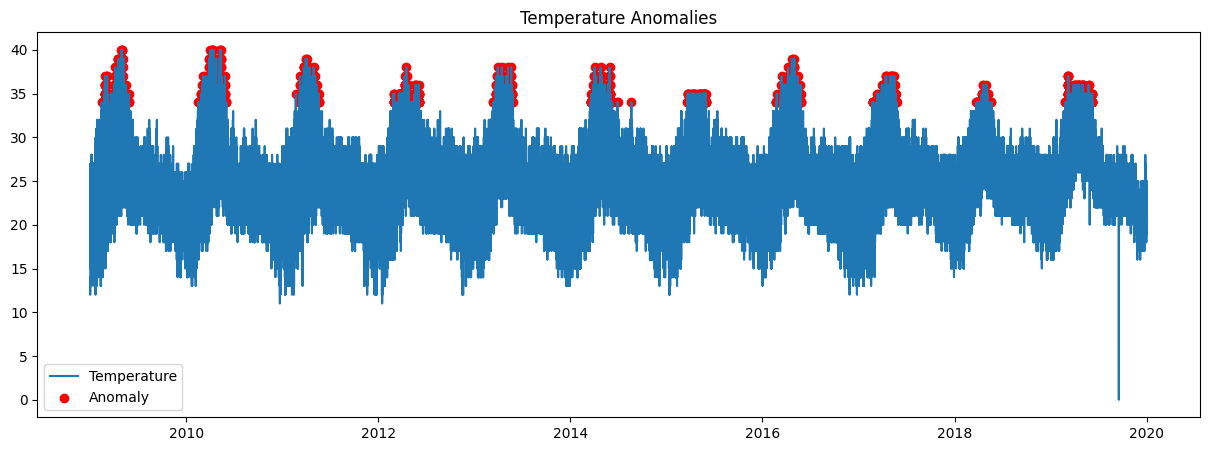

In [23]:
#Plot Anomalies
plt.figure(figsize=(15,5))

plt.plot(
    weather['date_time'],
    weather['tempC'],
    label='Temperature'
)

plt.scatter(
    anomalies['date_time'],
    anomalies['tempC'],
    color='red',
    label='Anomaly'
)

plt.legend()

plt.title('Temperature Anomalies')

plt.show()

In [25]:
#Prepare Data For Prophet
prophet_df = weather[
    ['date_time','tempC']
]

prophet_df.columns = ['ds','y']

In [26]:
#View Prophet Data
prophet_df.head()

,ds,y
0,2009-01-01 00:00:00,14
1,2009-01-01 01:00:00,14
2,2009-01-01 02:00:00,13
3,2009-01-01 03:00:00,12
4,2009-01-01 04:00:00,14


In [37]:
#Create Prophet Model
model = Prophet()

In [38]:
#Train Model
model.fit(prophet_df)

20:28:45 - cmdstanpy - INFO - Chain [1] start processing
20:30:19 - cmdstanpy - INFO - Chain [1] done processing


In [39]:
#Create Future Dates
future = model.make_future_dataframe(
    periods=30
)

In [40]:
#Predict Future Weather
forecast = model.predict(future)

In [41]:
#View Forecast Data
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
96457,2020-01-27 23:00:00,19.201043,16.964007,21.632764
96458,2020-01-28 23:00:00,19.288257,16.864878,21.743077
96459,2020-01-29 23:00:00,19.370830,17.034126,21.853489
96460,2020-01-30 23:00:00,19.531133,17.066097,21.928112
96461,2020-01-31 23:00:00,19.549506,17.131577,21.877635


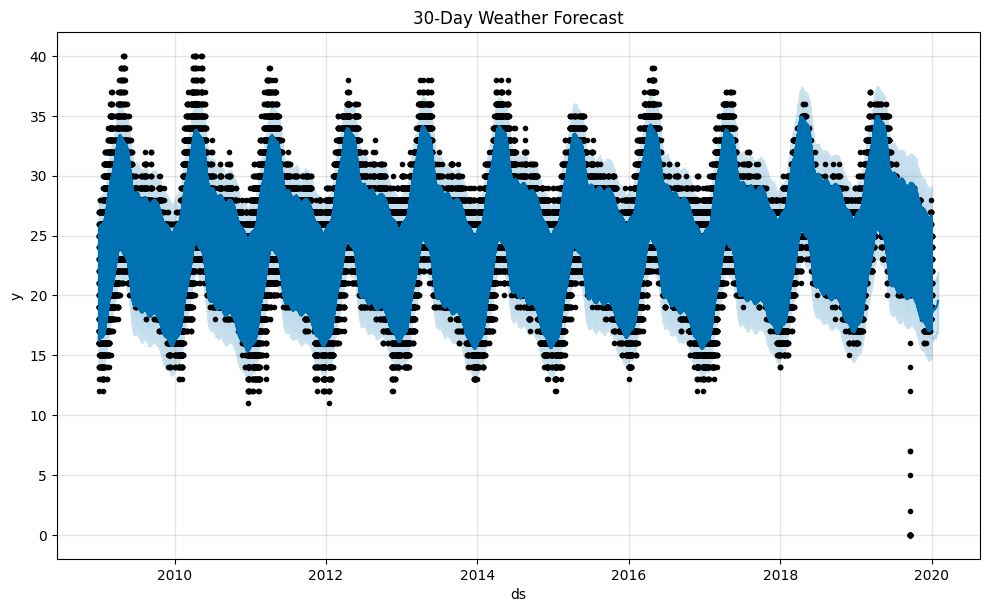

In [35]:
#Plot Forecast
model.plot(forecast)

plt.title('30-Day Weather Forecast')

plt.show()

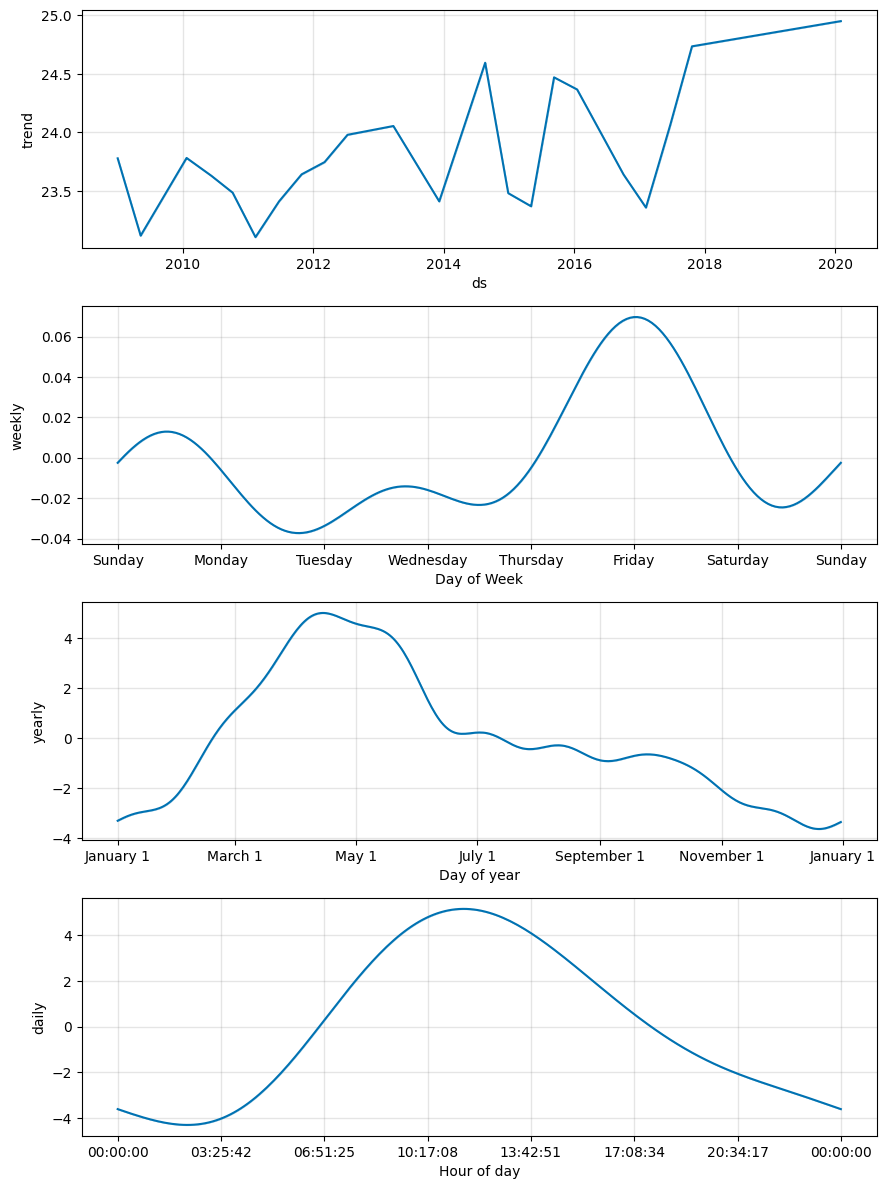

In [43]:
#Plot Forecast Components
model.plot_components(forecast)

plt.show()

In [44]:
#Save Forecast CSV
forecast.to_csv(
    'forecast_output.csv',
    index=False
)

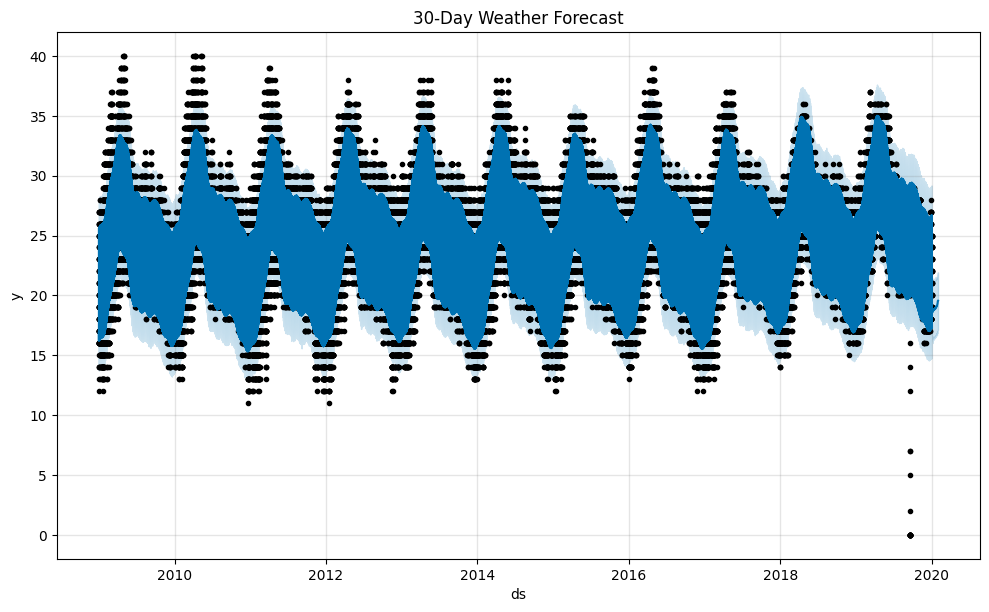

In [45]:
#Save Forecast Graph
fig = model.plot(forecast)

plt.title('30-Day Weather Forecast')

plt.savefig('forecast_graph.png')

plt.show()

In [46]:
#Final Completion Message
print("Weather Forecasting Project Completed Successfully")

Weather Forecasting Project Completed Successfully


In [47]:
forecast.to_csv('forecast_output.csv', index=False)

In [48]:
# Save only important forecast columns
small_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

# Save last 100 rows only
small_forecast.tail(100).to_csv(
    'forecast_output.csv',
    index=False
)